In [1]:
import numpy as np
import time
import pandas as pd 
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [2]:
##TO ZOSTAJE, GIT
full_R = np.load("../data/processed/R_dataset_full.npz", allow_pickle=True)
X_full_R  = full_R["X"]
K0_full_R = full_R["K0"]

##3 values - new
full_R_477 = np.load("../data/processed/R_dataset_full_477.npz", allow_pickle=True)
X_full_R_477  = full_R_477["X"]
K0_full_R_477 = full_R_477["K0"]

##git
full_477 = np.load("../data/processed/dataset_full_k477.npz", allow_pickle=True)
X_full_477  = full_477["X"]
K0_full_477 = full_477["K0"]

In [3]:
X_full_477

array([[ 16336., 102831., 247964., ...,  13860.,   5166.,   3647.],
       [ 16337., 102974., 248526., ...,  13485.,   5202.,   3483.],
       [ 16380., 103075., 248500., ...,  12860.,   5332.,   3248.],
       ...,
       [ 16356., 102612., 246888., ...,  14160.,   4104.,   6200.],
       [ 16332., 102349., 246076., ...,  13187.,   4204.,   5804.],
       [ 16352., 102583., 246812., ...,  13907.,   4288.,   6710.]],
      shape=(278084, 31))

In [4]:
X_full_R

array([[1.63630e+04, 1.12176e+05, 1.16367e+00],
       [1.63810e+04, 1.11976e+05, 1.16367e+00],
       [1.63560e+04, 1.11724e+05, 1.16367e+00],
       ...,
       [1.63790e+04, 1.03272e+05, 1.20459e+00],
       [1.63550e+04, 1.02958e+05, 1.20459e+00],
       [1.63400e+04, 1.02878e+05, 1.20459e+00]], shape=(1551444, 3))

In [12]:
train = np.load("../data/processed/dataset_train_shortened.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]

full = np.load("../data/processed/dataset_full.npz", allow_pickle=True)
X_full  = full["X"]
K0_full = full["K0"]

In [13]:
# mask = (K0_full == 4.77)
# X_masked = X_full[mask]
# X_full_477_minus1 = np.delete(X_full_477, 5, axis=1)
# print(np.allclose(X_masked, X_full_477_minus1))  # czy identyczne?
# print(len(X_masked), len(X_full_477[::100]))    

# print(X_masked[:4])
# print("####################")
# # print(X_full_477[:4].astype(int))

In [14]:
def build_model(base_model, calibrated=False):
    pipe = Pipeline([
        # ("scaler", StandardScaler()),
        ("clf", base_model)
    ])
    if not calibrated:
        return pipe


def run_supervised_pipeline(model, X_train, y_train, X_full):
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)

    if hasattr(model, "predict_proba"):
        print("pipipupu")
        P_A = model.predict_proba(X_full)[:, 1]
    else:
        print("pupupipi")
        scores = model.decision_function(X_full)
        P_A = 1.0 / (1.0 + np.exp(-scores))

    return train_score, P_A


In [15]:
k4771 = np.delete(X_full_477, 3, axis=1)
k4771

array([[ 16336., 102831., 247964., ...,  13860.,   5166.,   3647.],
       [ 16337., 102974., 248526., ...,  13485.,   5202.,   3483.],
       [ 16380., 103075., 248500., ...,  12860.,   5332.,   3248.],
       ...,
       [ 16356., 102612., 246888., ...,  14160.,   4104.,   6200.],
       [ 16332., 102349., 246076., ...,  13187.,   4204.,   5804.],
       [ 16352., 102583., 246812., ...,  13907.,   4288.,   6710.]],
      shape=(278084, 30))

In [16]:
# =============================================================================
# MAIN
# =============================================================================



models = {
    "Logistic Regression": LogisticRegression(),
}

for name, base_model in models.items():
    print(f"\n{'='*50}\nModel: {name}\n{'='*50}")

    for calibrated in [False]:
        label = "calibrated" if calibrated else "uncalibrated"
        model = build_model(base_model, calibrated=calibrated)
        k_target = 4.77
        mask = (K0_full == k_target)
        X_full_k477 = X_full[mask]
        # k477 = np.delete(X_full_477, 5, axis=1)
        # print(k477[::4])
        k477 = X_full_k477[::100]
        
        t0 = time.perf_counter()
        train_score, P_A = run_supervised_pipeline(model, X_train, y_train, k477)
        elapsed = time.perf_counter() - t0

        
       


Model: Logistic Regression
pipipupu


In [17]:
P_A

array([3.44367327e-05, 8.18852555e-05, 2.91351371e-01, ...,
       7.25874658e-05, 3.01753765e-03, 2.30246726e-03], shape=(2781,))

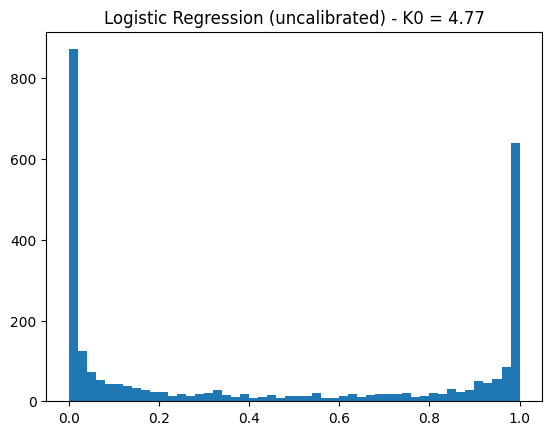

In [18]:
plt.hist(P_A, bins=50)
plt.title(f"{name} ({label}) - K0 = 4.77")
plt.show()